<a href="https://colab.research.google.com/github/ManjitYad01/PMS/blob/main/SentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import re

# Load the dataset
file_path = 'Reviews.xlsx'  # Replace with the actual file path
df = pd.read_excel(file_path)

# Function to clean text by removing emojis, special characters, and extra spaces
def clean_text(text):
    # Remove emojis and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning function to the 'Text' column
df['Cleaned_Text'] = df['Text'].apply(clean_text)

# Rearrange columns
cleaned_df = df[['ID', 'Cleaned_Text', 'Source', 'Timestamp']]

# Save the cleaned data to a new file
output_path = 'Cleaned_Data.xlsx'  # Replace with your desired save location
cleaned_df.to_excel(output_path, index=False)

# Display the cleaned data
print(cleaned_df.head())

   ID                                  Cleaned_Text          Source  \
0   1    Amazing quality and service best recommend  Product Review   
1   2    Amazing quality and service best recommend         Twitter   
2   3                 Its fine does the job neutral  Product Review   
3   4  Completely useless Dont waste your money bad  Product Review   
4   5      Very satisfied with this purchase 5stars    Public Forum   

             Timestamp  
0  2024-12-01 15:18:14  
1  2024-12-03 21:33:59  
2  2024-12-02 09:05:48  
3  2024-12-03 04:45:05  
4  2024-12-04 10:16:32  


After generating the cleaned data now it's time to drop some unnecessary columns like "Timestamp" and add some columns like "Ratings" and "sentiments" which will be essential for training the sentiment analysis model.


In [ ]:
# Import necessary libraries
import pandas as pd
import random

# Load the cleaned dataset
file_path = '/content/Cleaned_Data.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path)

# Function to assign ratings (1 to 5) based on sentiment
def assign_rating(cleaned_text):
    if "love" in cleaned_text or "amazing" in cleaned_text or "awesome" in cleaned_text:
        return random.choice([4, 5])  # Positive sentiments
    elif "terrible" in cleaned_text or "worst" in cleaned_text or "poor" in cleaned_text:
        return random.choice([1, 2])  # Negative sentiments
    else:
        return random.choice([3])  # Neutral sentiments

# Function to assign sentiment based on keywords
def assign_sentiment(cleaned_text):
    if "love" in cleaned_text or "amazing" in cleaned_text or "awesome" in cleaned_text:
        return "Positive"
    elif "terrible" in cleaned_text or "worst" in cleaned_text or "poor" in cleaned_text:
        return "Negative"
    else:
        return "Neutral"

# Apply functions to create Ratings and Sentiment columns
df['Rating'] = df['Cleaned_Text'].apply(assign_rating)
df['Sentiment'] = df['Cleaned_Text'].apply(assign_sentiment)

# Drop the Timestamp column
df = df.drop(columns=['Timestamp'])

# Save the updated dataset to a new Excel file
output_path = '/content/Cleaned_Data_With_Ratings_and_Sentiment.xlsx'
df.to_excel(output_path, index=False)

# Display the updated dataset
print(df.head())

# Notify user about the saved file
print(f"Updated cleaned data has been saved to {output_path}")


   ID                                  Cleaned_Text          Source  Rating  \
0   1    Amazing quality and service best recommend  Product Review       3   
1   2    Amazing quality and service best recommend         Twitter       3   
2   3                 Its fine does the job neutral  Product Review       3   
3   4  Completely useless Dont waste your money bad  Product Review       3   
4   5      Very satisfied with this purchase 5stars    Public Forum       3   

  Sentiment  
0   Neutral  
1   Neutral  
2   Neutral  
3   Neutral  
4   Neutral  
Updated cleaned data has been saved to /content/Cleaned_Data_With_Ratings_and_Sentiment.xlsx


Now, we are performing tokenization of our data.

In [ ]:
# Import necessary libraries
import pandas as pd
from nltk.tokenize import word_tokenize
import nltk

# Download NLTK data (if not already downloaded)
nltk.download('punkt')

# Load the cleaned dataset with ratings and sentiments
file_path = '/content/Cleaned_Data_With_Ratings_and_Sentiment.xlsx'  # Replace with your file path
df = pd.read_excel(file_path)

# Function to tokenize the cleaned text
def tokenize_text(text):
    return word_tokenize(text)

# Apply tokenization to the 'Cleaned_Text' column
df['Tokens'] = df['Cleaned_Text'].apply(tokenize_text)

# Save the tokenized dataset to a new Excel file
output_path = '/content/Tokenized_Data_With_Ratings_and_Sentiment.xlsx'
df.to_excel(output_path, index=False)

# Display a few rows of the tokenized data
print(df.head())

# Notify user about the saved file
print(f"Tokenized data has been saved to {output_path}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


   ID                                  Cleaned_Text          Source  Rating  \
0   1    Amazing quality and service best recommend  Product Review       3   
1   2    Amazing quality and service best recommend         Twitter       3   
2   3                 Its fine does the job neutral  Product Review       3   
3   4  Completely useless Dont waste your money bad  Product Review       3   
4   5      Very satisfied with this purchase 5stars    Public Forum       3   

  Sentiment                                             Tokens  
0   Neutral  [Amazing, quality, and, service, best, recommend]  
1   Neutral  [Amazing, quality, and, service, best, recommend]  
2   Neutral               [Its, fine, does, the, job, neutral]  
3   Neutral  [Completely, useless, Dont, waste, your, money...  
4   Neutral    [Very, satisfied, with, this, purchase, 5stars]  
Tokenized data has been saved to /content/Tokenized_Data_With_Ratings_and_Sentiment.xlsx


The code below is to import NLTK which is essential for our tokenization.

In [ ]:
import nltk

# Download punkt tokenizer again
nltk.download('punkt')

# Ensure all required NLTK resources are downloaded
nltk.download('all')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | D

True

Time to perform EDA and Visualization to generate Insight from the cleaned data

<ipython-input-14-10b0ed944fb4>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='Set2')


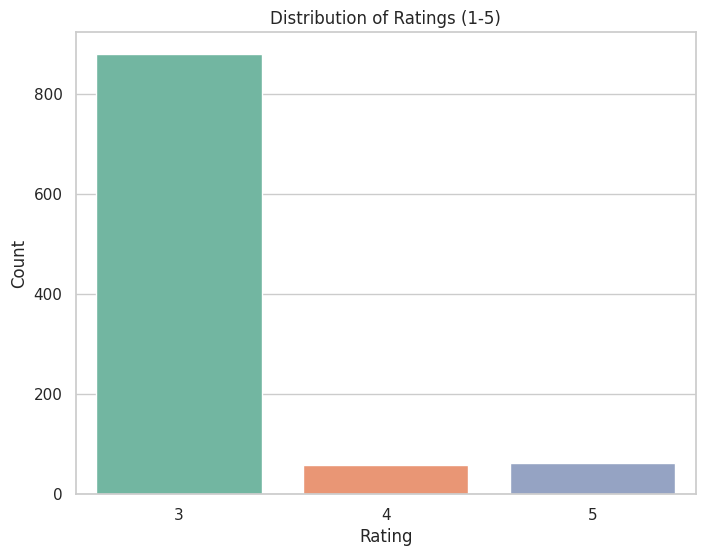

<ipython-input-14-10b0ed944fb4>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='Set1')


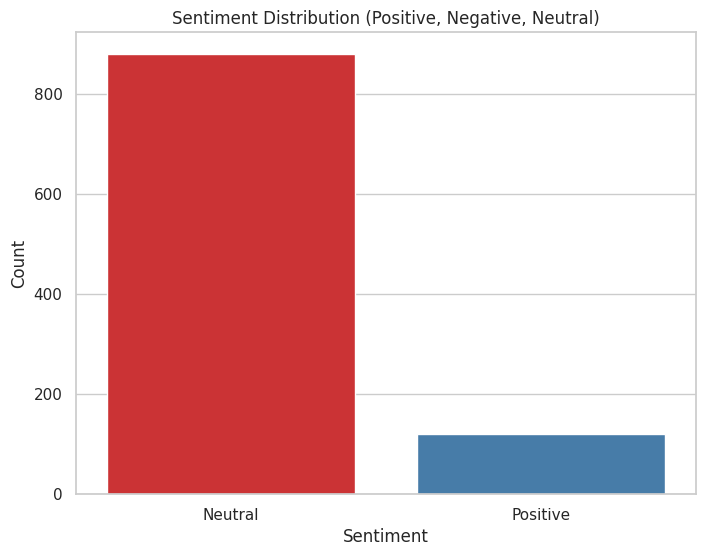

<ipython-input-14-10b0ed944fb4>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(tokens), palette='Blues_d')


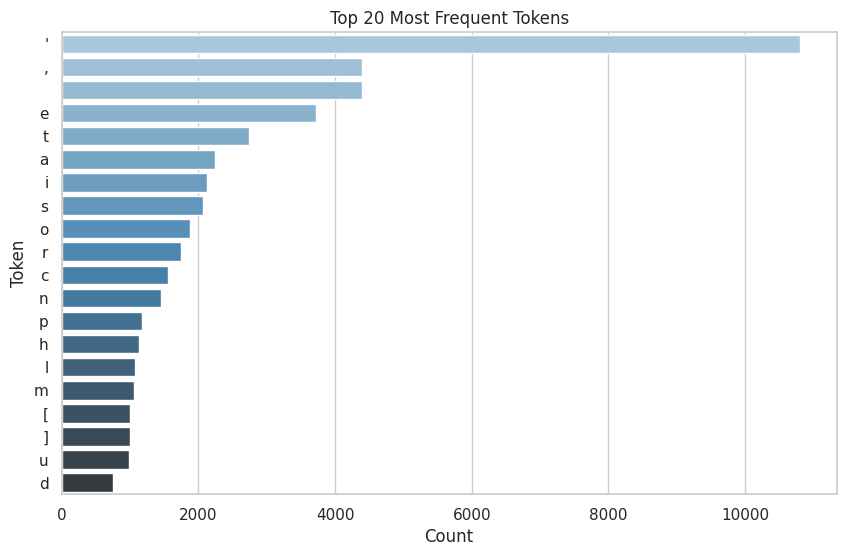

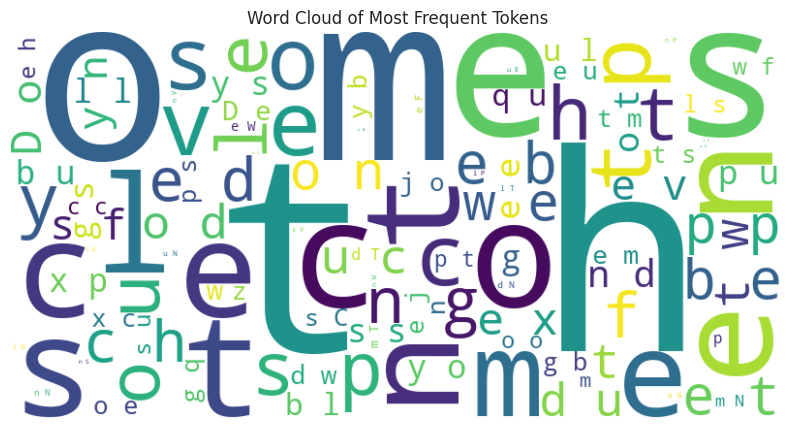

EDA plots saved to: 
/content/rating_distribution.png
/content/sentiment_distribution.png
/content/most_frequent_tokens.png
/content/wordcloud.png


In [ ]:
# Import necessary libraries for EDA and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Load the tokenized dataset with ratings and sentiments
file_path = '/content/Tokenized_Data_With_Ratings_and_Sentiment.xlsx'  # Replace with your file path
df = pd.read_excel(file_path)

# Set Seaborn style for plots
sns.set(style="whitegrid")

# 1. Plot the distribution of ratings (1-5)
plt.figure(figsize=(8, 6))
sns.countplot(x='Rating', data=df, palette='Set2')
plt.title('Distribution of Ratings (1-5)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
rating_plot_path = '/content/rating_distribution.png'
plt.savefig(rating_plot_path)
plt.show()

# 2. Plot the sentiment distribution (Positive, Negative, Neutral)
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df, palette='Set1')
plt.title('Sentiment Distribution (Positive, Negative, Neutral)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
sentiment_plot_path = '/content/sentiment_distribution.png'
plt.savefig(sentiment_plot_path)
plt.show()

# 3. Most Frequent Tokens (excluding stopwords)
all_tokens = [token for tokens in df['Tokens'] for token in tokens]
token_counts = Counter(all_tokens)

# Most common tokens
most_common_tokens = token_counts.most_common(20)
tokens, counts = zip(*most_common_tokens)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(tokens), palette='Blues_d')
plt.title('Top 20 Most Frequent Tokens')
plt.xlabel('Count')
plt.ylabel('Token')
most_frequent_tokens_plot_path = '/content/most_frequent_tokens.png'
plt.savefig(most_frequent_tokens_plot_path)
plt.show()

# 4. Generate a Word Cloud from tokenized data (excluding stopwords)
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=None).generate(' '.join(all_tokens))

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Tokens')
wordcloud_plot_path = '/content/wordcloud.png'
plt.savefig(wordcloud_plot_path)
plt.show()

# Notify about the saved images
print(f"EDA plots saved to: \n{rating_plot_path}\n{sentiment_plot_path}\n{most_frequent_tokens_plot_path}\n{wordcloud_plot_path}")

Now performing feature Engineering before vectorization of the data.

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Load the tokenized dataset with ratings and sentiments
file_path = '/content/Tokenized_Data_With_Ratings_and_Sentiment.xlsx'  # Replace with your file path
df = pd.read_excel(file_path)

# Preprocess the text for CountVectorizer and handle missing values
df['Cleaned_Text'] = df['Cleaned_Text'].astype(str).fillna('')
df['Rating'] = df['Rating'].fillna(0).astype(int)

# Encode sentiments (positive, negative, neutral) into numeric labels (0, 1, 2)
sentiment_encoder = LabelEncoder()
df['Sentiment_encoded'] = sentiment_encoder.fit_transform(df['Sentiment'])

# Extract features (Cleaned_Text and Rating) and target (Sentiment_encoded)
X = df[['Cleaned_Text', 'Rating']]  # Features: reviews and ratings
y = df['Sentiment_encoded']  # Target: sentiment (encoded as numeric)

# Vectorize the 'Cleaned_Text' using CountVectorizer and combine with ratings
vectorizer = CountVectorizer(stop_words='english', max_features=5000)

# Create a pipeline for feature engineering and model training
pipeline = Pipeline([
    ('features', ColumnTransformer([
        ('text', vectorizer, 'Cleaned_Text'),  # Transform text data
        ('rating', 'passthrough', ['Rating'])  # Use the Rating column directly
    ])),
    ('classifier', MultinomialNB())  # Classifier (Naive Bayes for text classification)
])

# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model's performance
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=sentiment_encoder.classes_))

# Save the trained model pipeline (optional for future use)
import joblib
model_path = '/content/sentiment_model.pkl'
joblib.dump(pipeline, model_path)

print(f"Model saved at {model_path}")


Classification Report:
              precision    recall  f1-score   support

     Neutral       1.00      1.00      1.00       174
    Positive       1.00      1.00      1.00        26

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Model saved at /content/sentiment_model.pkl


testing model

In [ ]:
import os
print(os.listdir())  # Ensure 'sentiment_model.pkl' is listed


['.config', 'sentiment_predictions.csv', 'sentiment_model.pkl', 'testing_data.xlsx', 'sample_data']


In [ ]:
import joblib

# Load the model pipeline
model_path = 'sentiment_model.pkl'  # Path to your saved model
pipeline = joblib.load(model_path)
print("Model loaded successfully!")


Model loaded successfully!


making prediction using the model

In [ ]:
# Make predictions using the loaded pipeline
predictions = pipeline.predict(testing_data.xlsx)

# Map the predictions to sentiment labels
sentiment_labels = pipeline.classes_
predicted_sentiments = sentiment_labels[predictions]

# Display the predictions
for review, rating, sentiment in zip(test_data, test_ratings, predicted_sentiments):
    print(f"Review: {review}\nRating: {rating}\nPredicted Sentiment: {sentiment}\n")



NameError: name 'testing_data' is not defined

eval


In [ ]:
from sklearn.metrics import accuracy_score

# Actual sentiments for comparison (encoded as integers: 0=positive, 1=negative, 2=neutral)
actual_sentiments = [0, 1, 2]  # Example actual sentiments

# Calculate accuracy
accuracy = accuracy_score(actual_sentiments, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 33.33%


save and share

In [ ]:
# Save predictions to a DataFrame
results = pd.DataFrame({
    'Review': test_data,
    'Rating': test_ratings,
    'Predicted_Sentiment': predicted_sentiments
})

# Save the results to a CSV file
results.to_csv('sentiment_predictions.csv', index=False)
print("Predictions saved to sentiment_predictions.csv")


Predictions saved to sentiment_predictions.csv


In [ ]:
import pandas as pd
import pickle
from sklearn.metrics import accuracy_score, classification_report

# Load data
data_file = "testing_data.xlsx"  # Replace with the correct path
df = pd.read_excel(data_file)

# Data cleaning
# Convert text to lowercase and remove special characters
def clean_text(text):
    text = text.lower()
    text = ''.join(char for char in text if char.isalnum() or char.isspace())
    return text

df['Cleaned_Review'] = df['Review'].apply(clean_text)

# Prepare data for testing
X_test = df[['Cleaned_Review', 'Rating']]
y_test = df['Sentiment']

# Load the trained pipeline
with open("pipeline.pkl", "rb") as pipeline_file:
    pipeline = pickle.load(pipeline_file)

# Make predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(report)

# Save the cleaned data with predictions (optional)
df['Predicted_Sentiment'] = y_pred
df.to_excel("cleaned_reviews_with_predictions.xlsx", index=False)


FileNotFoundError: [Errno 2] No such file or directory: 'pipeline.pkl'